# PCA & Dimensionality Reduction Analysis
## London Urban Safety Classification

This notebook implements a complete dimensionality reduction analysis for the 4 features in your urban safety model:
- lighting, visibility, connectivity, enclosure

**Steps:**
1. Load & explore features
2. Correlation analysis
3. Standardize features
4. Apply PCA (all components)
5. Interpret loadings & variance
6. Make reduction decision
7. Compare model performance (original vs. reduced)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# Set visualization defaults
sns.set_style('darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✓ All imports successful')

✓ All imports successful


## Step 1: Load & Prepare Data

**Data source:** `segment_risk_scores_w-id.csv` 
- Features: lighting, visibility, connectivity, enclosure, transport proximity, land-use (all normalized)
- Target: risk_class (3 classes: 'low', 'medium', 'high')
- Includes borough and location_id for reference


In [4]:
# ====================================================================================
# Load features with updated 4-class safety classification
# ====================================================================================

print('Loading feature data...')

# Define feature columns
FEATURE_COLS = ['lighting', 'visibility', 'connectivity', 'enclosure', 'dominant_land_use_score', 'public_transport_proximity_m']

csv_path = r'C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv'
try:
    features = pd.read_csv(csv_path, dtype={'risk_score': str})
    print(f'✓ Loaded features from {csv_path}: {len(features)} rows')
except FileNotFoundError:
    print(f'! CSV file not found: {csv_path}')
    print('  Run 00_DataFetching.ipynb first to generate segment_risk_scores_w-id.csv')
    raise

# Extract features and target
X = features[FEATURE_COLS].dropna()
y = features.loc[X.index, 'risk_score'].astype(str)

print(f'\nData shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')


Loading feature data...
✓ Loaded features from C:\Users\maria\Documents\GitHub\MaCAD26-G01-DataEncoding\csv\segment_risk_scores_w-id.csv: 35978 rows

Data shape: (26221, 6)
Target distribution:
risk_score
0.5500884206891141     2
0.5865666974301141     2
0.555791109926954      2
0.5703185389327892     2
0.5784633248194084     2
                      ..
0.6058479076055945     1
0.656551501734469      1
0.49204811287800426    1
0.6351109233773685     1
0.7585728248804394     1
Name: count, Length: 15877, dtype: int64


## Step 2: Exploratory Data Analysis (EDA)

### 2.1 Feature Statistics & Distributions

In [5]:
# Feature statistics BEFORE scaling
print('='*70)
print('FEATURE STATISTICS (BEFORE SCALING)')
print('='*70)

stats = X.describe().T
stats['variance'] = X.var()
print(stats.round(4))

print('\nKey observations:')
print(f'  - Highest variance: {stats["variance"].idxmax()} ({stats["variance"].max():.2f})')
print(f'  - Lowest variance: {stats["variance"].idxmin()} ({stats["variance"].min():.2f})')
print(f'  - Variance ratio (max/min): {stats["variance"].max() / stats["variance"].min():.2f}x')
print('\n→ Features have different scales. StandardScaler is ESSENTIAL for PCA!')

FEATURE STATISTICS (BEFORE SCALING)
                                  count     mean     std     min     25%  \
lighting                     26221.0000   2.2762  6.2744  0.0000  0.0000   
visibility                   26221.0000   9.3666  5.9619  0.0000  8.6250   
connectivity                 26221.0000  10.3940  2.3507  3.0000  8.0000   
enclosure                    26221.0000   0.3031  0.1542  0.0000  0.2058   
dominant_land_use_score      26221.0000  -0.6189  0.5756 -1.0000 -1.0000   
public_transport_proximity_m 26221.0000 106.1485 71.2985  0.4500 51.9100   

                                 50%      75%      max  variance  
lighting                      0.0000   1.7773 163.3904   39.3686  
visibility                    9.0000  10.2000 180.0000   35.5439  
connectivity                 11.0000  12.0000  17.0000    5.5257  
enclosure                     0.2860   0.3916   1.1360    0.0238  
dominant_land_use_score      -0.9395  -0.4438   1.0000    0.3313  
public_transport_proximity_m 

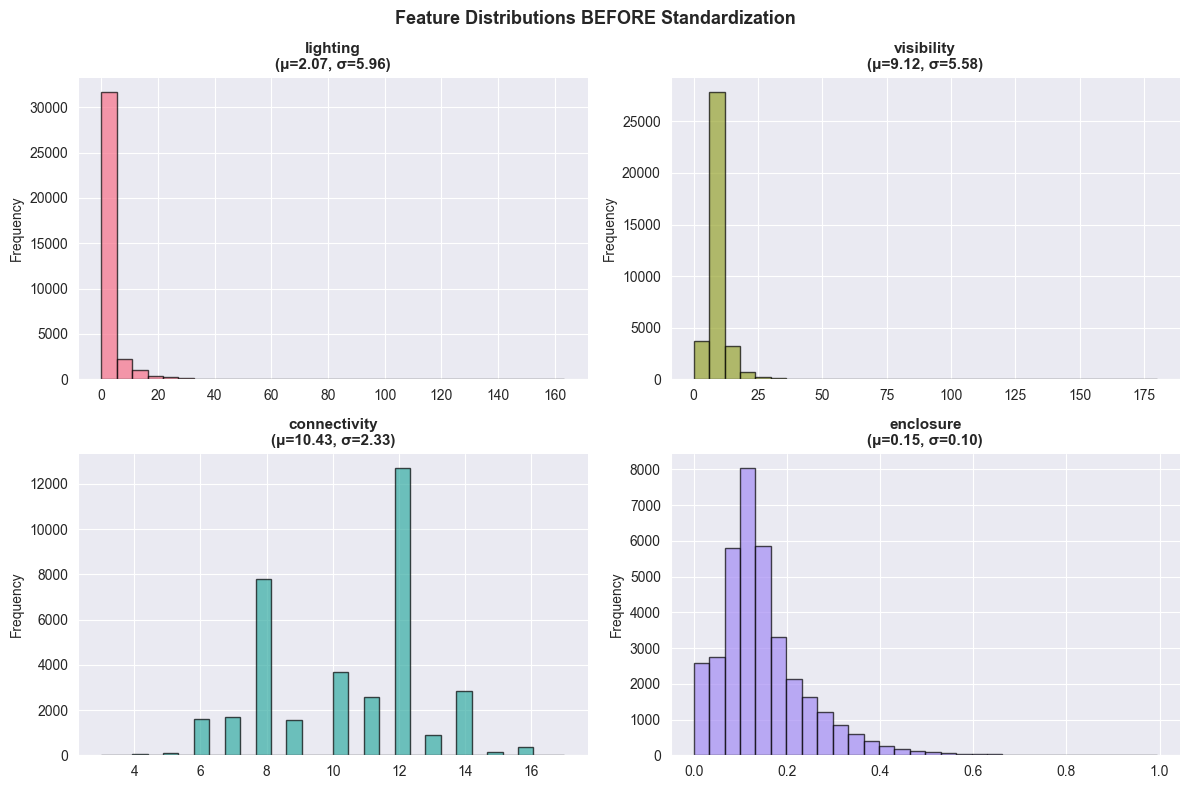

In [ ]:
# Visualize feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors_palette = sns.color_palette('husl', 4)

for ax, col, color in zip(axes.flat, FEATURE_COLS, colors_palette):
    ax.hist(X[col].dropna(), bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}\n(μ={X[col].mean():.2f}, σ={X[col].std():.2f})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Feature Distributions BEFORE Standardization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Correlation Analysis

**Question:** Are any features highly correlated (redundant)?

In [ ]:
# Compute correlation matrix
corr_matrix = X[FEATURE_COLS].corr()

print('Correlation Matrix:')
print(corr_matrix.round(3))

print('\nCorrelation Pairs (sorted by absolute value):')
# Extract upper triangle (avoid duplicates)
corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1, col2 = corr_matrix.columns[i], corr_matrix.columns[j]
        corr_val = corr_matrix.loc[col1, col2]
        corr_pairs.append((col1, col2, corr_val))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)
for col1, col2, corr_val in corr_pairs_sorted:
    print(f'  {col1:15s} ↔ {col2:15s}: {corr_val:7.3f}')

print('\nInterpretation:')
print('  |r| > 0.8  → Strong correlation (redundant features)')
print('  |r| 0.5-0.8 → Moderate correlation')
print('  |r| < 0.5  → Weak correlation (independent)')

Correlation Matrix:
              lighting  visibility  connectivity  enclosure
lighting        1.0000     -0.0410       -0.1110    -0.0280
visibility     -0.0410      1.0000        0.0220     0.4430
connectivity   -0.1110      0.0220        1.0000    -0.0450
enclosure      -0.0280      0.4430       -0.0450     1.0000

Correlation Pairs (sorted by absolute value):
  visibility      ↔ enclosure      :   0.443
  lighting        ↔ connectivity   :  -0.111
  connectivity    ↔ enclosure      :  -0.045
  lighting        ↔ visibility     :  -0.041
  lighting        ↔ enclosure      :  -0.028
  visibility      ↔ connectivity   :   0.022

Interpretation:
  |r| > 0.8  → Strong correlation (redundant features)
  |r| 0.5-0.8 → Moderate correlation
  |r| < 0.5  → Weak correlation (independent)


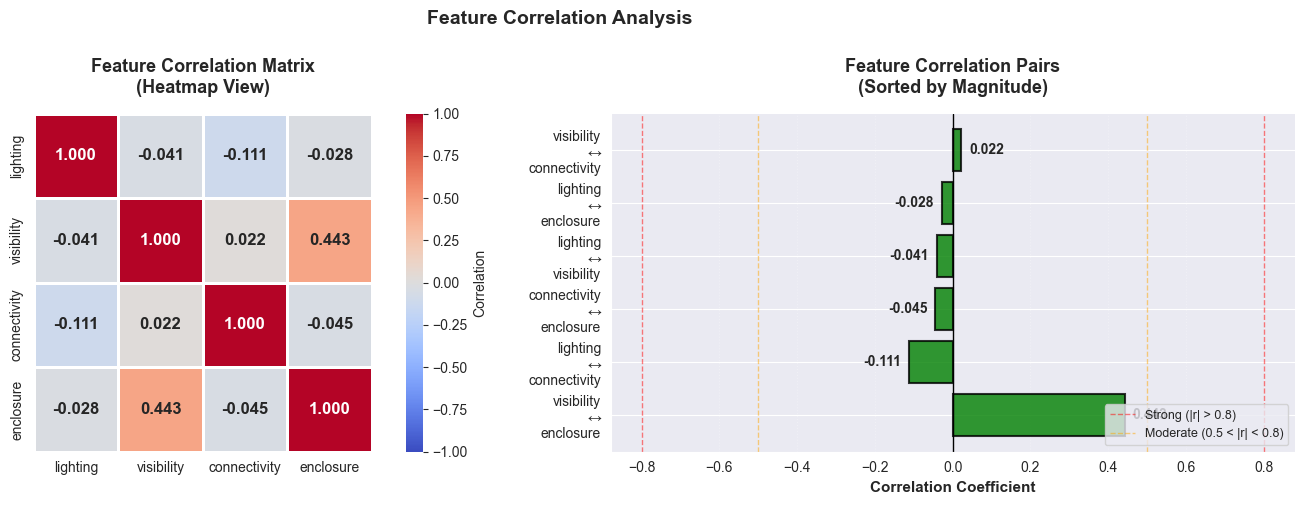

In [ ]:
# Visualize correlations: Heatmap + Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Correlation Heatmap
ax1 = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=2, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'}, ax=ax1)
ax1.set_title('Feature Correlation Matrix\n(Heatmap View)', fontsize=13, fontweight='bold', pad=15)

# Plot 2: Correlation Pairs as Bar Chart
ax2 = axes[1]
pair_labels = [f'{col1}\n↔\n{col2}' for col1, col2, _ in corr_pairs_sorted]
pair_values = [val for _, _, val in corr_pairs_sorted]
colors = ['green' if abs(v) < 0.5 else 'orange' if abs(v) < 0.8 else 'red' for v in pair_values]

bars = ax2.barh(range(len(pair_labels)), pair_values, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_yticks(range(len(pair_labels)))
ax2.set_yticklabels(pair_labels, fontsize=10)
ax2.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
ax2.set_title('Feature Correlation Pairs\n(Sorted by Magnitude)', fontsize=13, fontweight='bold', pad=15)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Strong (|r| > 0.8)')
ax2.axvline(x=-0.8, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Moderate (0.5 < |r| < 0.8)')
ax2.axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(axis='x', alpha=0.3, linestyle=':')
ax2.legend(fontsize=9, loc='lower right')
ax2.spines[['top', 'right']].set_visible(False)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, pair_values)):
    ax2.text(val + 0.02 if val > 0 else val - 0.02, i, f'{val:.3f}', 
             va='center', ha='left' if val > 0 else 'right', fontweight='bold', fontsize=10)

plt.suptitle('Feature Correlation Analysis', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


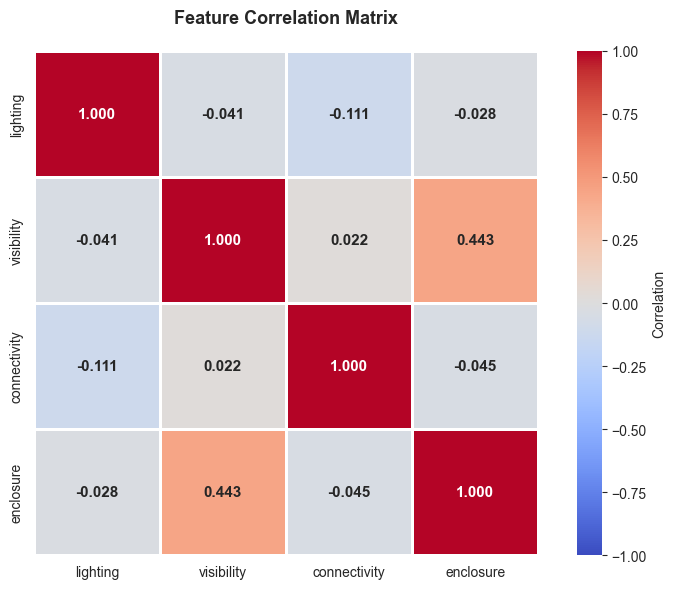

In [ ]:
# Visualize correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={'label': 'Correlation'},
            annot_kws={'fontsize': 11, 'fontweight': 'bold'})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()